<a href="https://colab.research.google.com/github/sophiadapot/stats507-coursework/blob/main/day5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Handwriting Detective
### Summer Camp Lab: Machine Learning with scikit-learn

Today you will teach a computer to read handwritten digits - and then break it on purpose.

**Six missions:**

1. Discover that an image is secretly just numbers
2. Meet the data
3. Train your first machine learning model
4. Look at every mistake it makes
5. **Break it** with noise and a one-pixel shift
6. Draw your own digit and see if it can read your handwriting
7. Bonus: repaint a photo using only 8 colors

**How to work:** run each cell with `Shift + Enter`. Cells that say `# YOUR CODE HERE`
are yours to fill in. Raise your hand if you're stuck for more than 5 minutes.

---

## Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets, svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("Ready to investigate.")

Ready to investigate.


---
# Mission 1 - An image is secretly just numbers

Before a computer can "see" a picture, the picture has to become numbers.

A grayscale image is a **grid of brightness values**. In our dataset every digit is an
**8 x 8 grid**, and each number goes from `0` (blank paper) up to `16` (heavy ink).

8 x 8 = **64 numbers**. That is the entire picture.

In [2]:
digits = datasets.load_digits()

# The 43rd image in the collection, printed as raw numbers
print(digits.images[42].astype(int))

[[ 0  0  0  0 12  5  0  0]
 [ 0  0  0  2 16 12  0  0]
 [ 0  0  1 12 16 11  0  0]
 [ 0  2 12 16 16 10  0  0]
 [ 0  6 11  5 15  6  0  0]
 [ 0  0  0  1 16  9  0  0]
 [ 0  0  0  2 16 11  0  0]
 [ 0  0  0  3 16  8  0  0]]


Squint at that grid - the big numbers trace out a shape. Now let's color them in
so we can see what the computer sees.

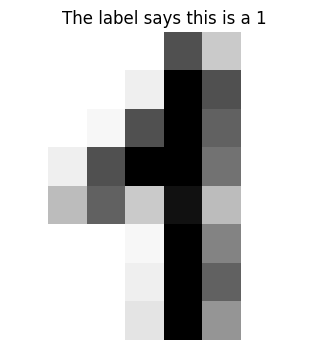

In [3]:
plt.figure(figsize=(4, 4))
plt.imshow(digits.images[42], cmap="Greys")
plt.title(f"The label says this is a {digits.target[42]}")
plt.axis("off")
plt.show()

### Task 1.1

Show a **different** digit. Pick any index between 0 and 1796.

Copy the cell above and change the two `42`s to your number.

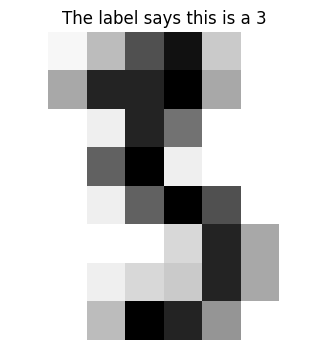

In [10]:
# YOUR CODE HERE
# Show a different digit and its label
plt.figure(figsize=(4, 4))
plt.imshow(digits.images[1670], cmap="Greys")
plt.title(f"The label says this is a {digits.target[1670]}")
plt.axis("off")
plt.show()


---
# Mission 2 - Meet the data

Machine learning always starts with two things:

- **X** = the inputs. Here: 1,797 digits, each one flattened into a row of 64 numbers.
- **y** = the answers, called **labels**. Here: which digit each image really is.

The whole game is learning a rule that turns X into y.

In [9]:
X = digits.data      # the images, 64 numbers each
y = digits.target    # the correct answers

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 20 answers:", y[:20])

X shape: (1797, 64)
y shape: (1797,)
First 20 answers: [0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9]


### Task 2.1 - Look at a handful of digits

Run this cell to see the first 10 images side by side. Notice how much the handwriting
varies - that's exactly what makes this hard.

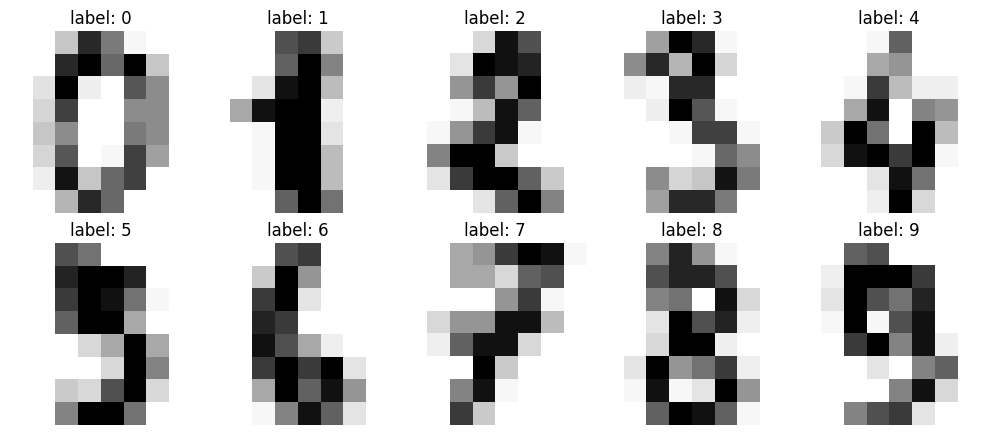

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))

for ax, image, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(image, cmap="Greys")
    ax.set_title(f"label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Talk to the person next to you:** are any of these hard for *you* to read?
If a human can't tell a 3 from an 8, should we expect the computer to?

---
# Mission 3 - Train your first model

Here is the most important rule in this entire lab:

> **Never test a model on data it already studied.**

If the model memorizes all 1,797 digits and we quiz it on those same digits, of course
it scores well. That's an open-book test where the student wrote the book.

So we **split** the data:

- **Training set (80%)** - the model studies these
- **Test set (20%)** - locked in a vault, used only for the final exam

### Task 3.1 - Split the data

Fill in `test_size=0.2` (20% for testing) and `random_state=42` (so everyone in the room
gets the same split).

In [15]:
# YOUR CODE HERE
# Fill in the two blanks below, then delete this comment and uncomment the lines

X_train, X_test, y_train, y_test = train_test_split(     X, y, test_size=0.2, random_state=42)

print("Training on", X_train.shape[0], "images")
print("Testing  on", X_test.shape[0], "images")

Training on 1437 images
Testing  on 360 images


### The model: a Support Vector Machine

An SVM draws **boundaries** between the classes. Picture red and blue marbles scattered
on a table, and you draw the line that separates them with the widest possible gap.

Our digits don't live on a table - they live in 64 dimensions, one per pixel. You can't
picture that, and that's fine. Nobody can. The math works anyway.

### Task 3.2 - Create the model and train it

Two lines:

```python
clf = svm.SVC(kernel="rbf", C=1)
clf.fit(X_train, y_train)
```

The `.fit()` step is the actual learning. Everything before this was preparation.

In [16]:
# YOUR CODE HERE
# Create the classifier, then fit it to the TRAINING data
clf = svm.SVC(kernel="rbf", C=1)
clf.fit(X_train, y_train)


SVC(C=1)

### Task 3.3 - The final exam

Now unlock the vault. Ask the model to predict labels for `X_test`, then score it.

```python
y_pred = clf.predict(X_test)
```

In [17]:
# YOUR CODE HERE
# Predict on the test set and store the result in y_pred
y_pred = clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.9861


You should get about **98.6%**.

Pause and appreciate that. You wrote about four lines of code and built something that
reads handwriting. Now let's find the cracks.

---
# Mission 4 - Look at the mistakes

98.6% accuracy means the model got about **5 images wrong** out of 360.

Those 5 are the interesting part. Let's put every single one on screen.

Number of mistakes: 5


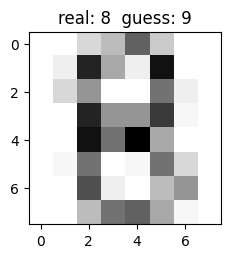

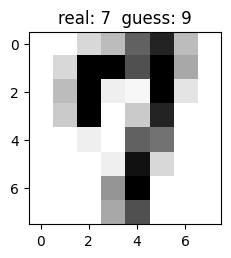

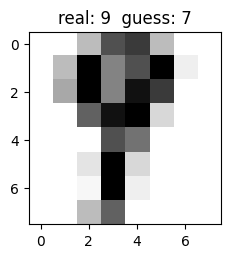

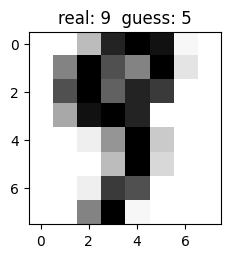

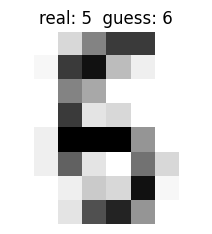

In [24]:
# Find the positions where the guess did not match the truth
wrong = np.where(y_pred != y_test)[0]

print("Number of mistakes:", len(wrong))
for pic in wrong:
  plt.figure(figsize=(10, 2.5))
  plt.imshow(X_test[pic].reshape(8, 8), cmap="Greys")
  plt.title(f"real: {y_test[pic]}  guess: {y_pred[pic]}")
plt.axis("off")
plt.show()

### Task 4.1 - The mistake gallery

Display each wrong image, titled with the real answer and the model's guess.

Two hints:
- `X_test[k]` is a flat row of 64 numbers, so use `.reshape(8, 8)` to turn it back into
  a picture
- loop with `for ax, k in zip(axes, wrong):`

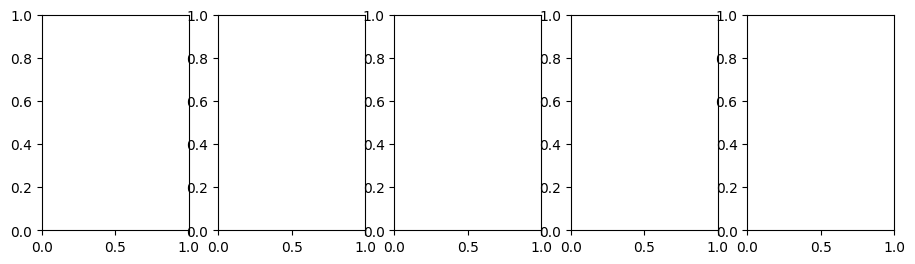

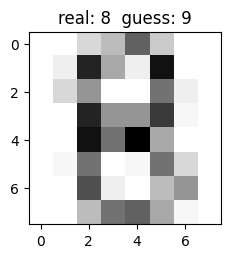

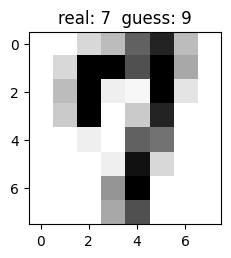

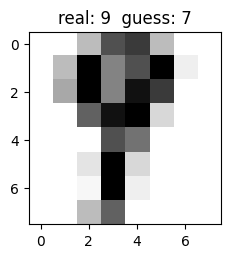

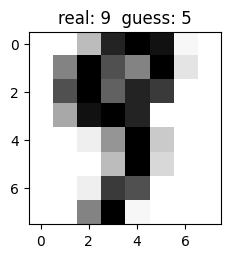

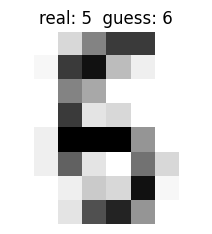

<Figure size 640x480 with 0 Axes>

In [26]:
n = len(wrong)
fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8))

# YOUR CODE HERE
# For each mistake, show the image with title "real: __  guess: __"
for pic in wrong:
  plt.figure(figsize=(10, 2.5))
  plt.imshow(X_test[pic].reshape(8,8), cmap="Greys")
  plt.title(f"real: {y_test[pic]}  guess: {y_pred[pic]}")
plt.axis("off")
plt.show()

plt.tight_layout()
plt.show()

**Vote as a class:** for each image, what would *you* have said?

Some of these are genuinely unreadable. That's an important thing to know about machine
learning - sometimes the "error" isn't the model being dumb, it's the data being messy.
A model can only be as good as what it was shown.

---
# Mission 5 - Break it

Your model looks brilliant. Let's find out how fragile it is.

It has never seen a smudged digit or an off-center digit. It only knows the world it was
trained on. **Let's leave that world.**

### Attack 1: noise (a bad photocopier)

noise level 0:  accuracy 0.986
noise level 2:  accuracy 0.981
noise level 4:  accuracy 0.969
noise level 8:  accuracy 0.725


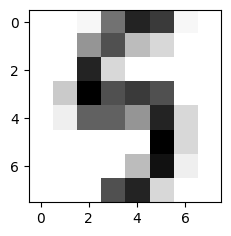

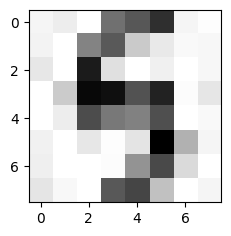

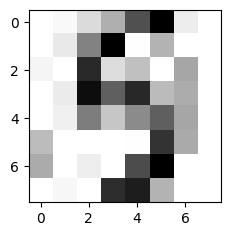

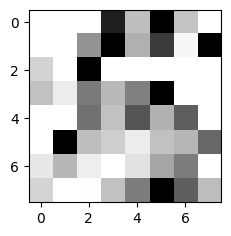

In [29]:
rng = np.random.default_rng(0)

def add_noise(data, level):
    """Sprinkle random speckle on every pixel."""
    return np.clip(data + rng.normal(0, level, data.shape), 0, 16)

for level in [0, 2, 4, 8]:
    noisy = add_noise(X_test, level)
    acc = accuracy_score(y_test, clf.predict(noisy))
    print(f"noise level {level}:  accuracy {acc:.3f}")
    plt.figure(figsize=(10, 2.5))
    plt.imshow(noisy[69].reshape(8,8), cmap="Greys")

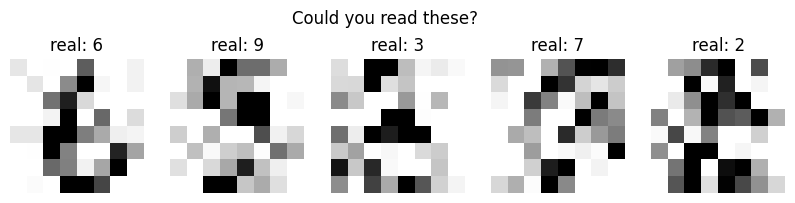

In [30]:
# What the model is being asked to read at noise level 8
noisy = add_noise(X_test, 8)

fig, axes = plt.subplots(1, 5, figsize=(10, 2.4))
for ax, k in zip(axes, range(5)):
    ax.imshow(noisy[k].reshape(8, 8), cmap="Greys")
    ax.set_title(f"real: {y_test[k]}")
    ax.axis("off")
plt.suptitle("Could you read these?")
plt.show()

### Attack 2: slide the digit one pixel to the right

This one is the shocker. Every digit stays perfectly readable to a human. We just move
it over by **one single pixel**.

**Before you run the next cell, guess the accuracy out loud.**

In [33]:
def shift_right(data, k=1):
    images = data.reshape(-1, 8, 8)
    return np.roll(images, k, axis=2).reshape(-1, 64)

for k in [0, 1, 2]:
    acc = accuracy_score(y_test, clf.predict(shift_right(X_test, k)))
    print(f"shifted {k} pixel(s):  accuracy {acc:.3f}")

shifted 0 pixel(s):  accuracy 0.986
shifted 1 pixel(s):  accuracy 0.525
shifted 2 pixel(s):  accuracy 0.158


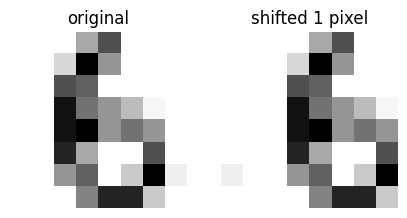

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.8))
axes[0].imshow(X_test[0].reshape(8, 8), cmap="Greys")
axes[0].set_title("original"); axes[0].axis("off")
axes[1].imshow(shift_right(X_test, 1)[0].reshape(8, 8), cmap="Greys")
axes[1].set_title("shifted 1 pixel"); axes[1].axis("off")
plt.show()

**Read that number again.** One pixel, and the model falls apart.

Why? The model has no idea what a "shape" is. Pixel #17 is just *pixel #17* to it, a
column in a spreadsheet. Slide the image over and every column now holds a different
value. It's like shuffling the questions on an exam but keeping the answer key in order.

This is exactly why **convolutional neural networks** were invented - they're built to
spot a shape *anywhere* in an image.

### Task 5.1 - Your turn to attack

Pick **one** and try it:

1. **Invert the ink** (white writing on black paper): `inverted = 16 - X_test`
2. **Mirror it** left to right: `np.flip(X_test.reshape(-1, 8, 8), axis=2).reshape(-1, 64)`

Then print the accuracy the same way we did above.

In [38]:
# YOUR CODE HERE
# Attack the model and report the damage
def invert(data):
  inverted = 16 - X_test
  return np.flip(X_test.reshape(-1, 8, 8), axis=2).reshape(-1, 64)

acc = accuracy_score(y_test, clf.predict(invert(X_test)))
print(f"inverted:  accuracy {acc:.3f}")

inverted:  accuracy 0.364


### The lesson

A model is not intelligent. It is **very good at the exact situation you trained it for,
and clueless one inch outside of it.**

Self-driving cars, medical scanners, and face unlock all live and die by this problem.

---
# Mission 6 - Draw your own digit

Enough theory. Can it read *your* handwriting?

Edit the drawing below on an 8 x 8 grid:
- `.` is blank paper
- `#` is ink

Keep it **8 rows tall and 8 characters wide**.

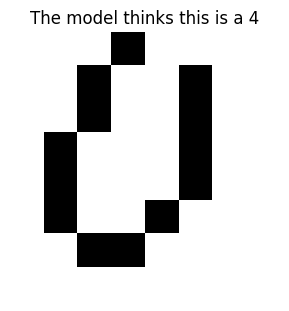

In [72]:
my_digit = """
...#....
..#..#..
..#..#..
.#...#..
.#...#..
.#..#...
..##....
........
"""


def art_to_image(art):
    """Turn 8 lines of '.' and '#' into an 8x8 grid of 0s and 16s."""
    rows = art.strip("\n").split("\n")
    rows = [r.ljust(8, ".")[:8] for r in rows]
    while len(rows) < 8:
        rows.append("." * 8)
    return np.array([[0.0 if ch == "." else 16.0 for ch in r] for r in rows[:8]])


image = art_to_image(my_digit)
guess = clf.predict(image.reshape(1, -1))[0]

plt.figure(figsize=(3.5, 3.5))
plt.imshow(image, cmap="Greys")
plt.title(f"The model thinks this is a {guess}")
plt.axis("off")
plt.show()

### Task 6.1 - Beat the detective

Go back to the cell above, change the drawing, and run it again. Try at least **four**
different digits and keep score:

| What you drew | What it guessed | Right? |
|---|---|---|
|  |  |  |
|  |  |  |
|  |  |  |
|  |  |  |

Then the real challenge: **draw a digit that fools it.** Write a 4 it calls a 9, or an 8
it calls a 3. You're allowed to write badly - that's the point.

**Hint:** it struggles most when your strokes are much thicker or thinner than the
training data, or when your digit hugs the edge instead of sitting in the center.

---
# Mission 7 (bonus) - Learning with no answers at all

Everything so far was **supervised learning**: every image came with the right answer
attached.

But most data in the world has **no labels**. Nobody has written down what's in every
photo on the internet. **Unsupervised learning** finds patterns anyway.

We'll use **K-Means clustering**, which does one simple thing: given a pile of points and
a number `k`, it finds `k` groups of similar points.

### Repaint a photo with only 8 colors

Here's the trick. A photo is a big pile of pixels, and every pixel is a point in color
space: (red, green, blue).

Run K-Means on those points with `k=8` and you get the 8 colors that best represent the
whole photo. Repaint every pixel with its group's color and you've built an **image
compressor**.

Total pixels: 273280


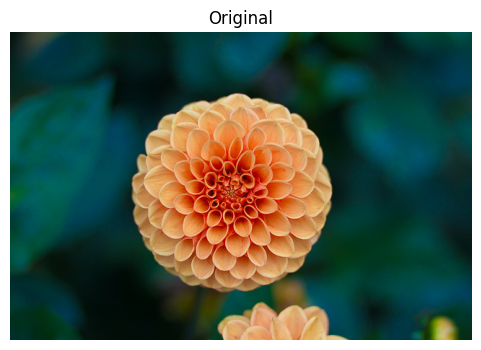

In [54]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_sample_image

photo = load_sample_image("flower.jpg") / 255.0
pixels = photo.reshape(-1, 3)

print("Total pixels:", len(pixels))

plt.figure(figsize=(6, 4))
plt.imshow(photo)
plt.axis("off")
plt.title("Original")
plt.show()

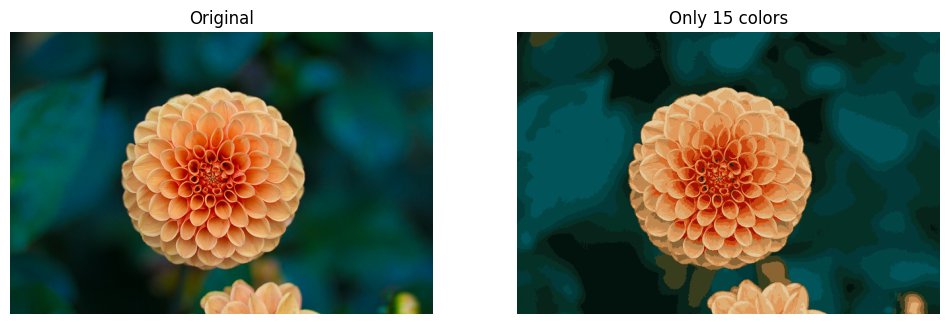

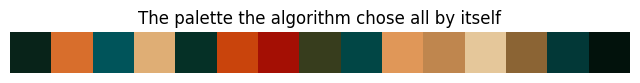

In [56]:
def repaint(k):
    """Reduce the photo to k colors using K-Means."""
    sample = pixels[np.random.default_rng(0).choice(len(pixels), 5000, replace=False)]
    km = KMeans(n_clusters=k, n_init=4, random_state=0).fit(sample)
    labels = km.predict(pixels)
    return km.cluster_centers_[labels].reshape(photo.shape), km.cluster_centers_


small, palette = repaint(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(photo); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(small); axes[1].set_title("Only 15 colors"); axes[1].axis("off")
plt.show()

plt.figure(figsize=(8, 1.2))
plt.imshow([palette])
plt.title("The palette the algorithm chose all by itself")
plt.axis("off")
plt.show()

### Task 7.1

Nobody told the algorithm which colors to use. It worked them out from the photo.

Try `repaint(2)`, `repaint(3)`, and `repaint(16)`. **What's the smallest number of colors
where the photo still looks okay to you?**

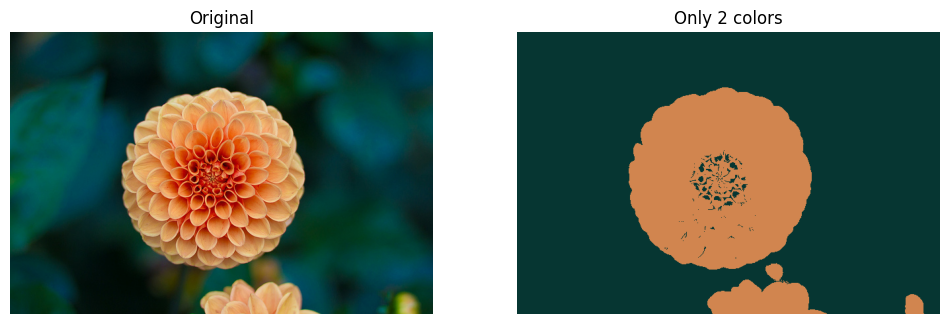

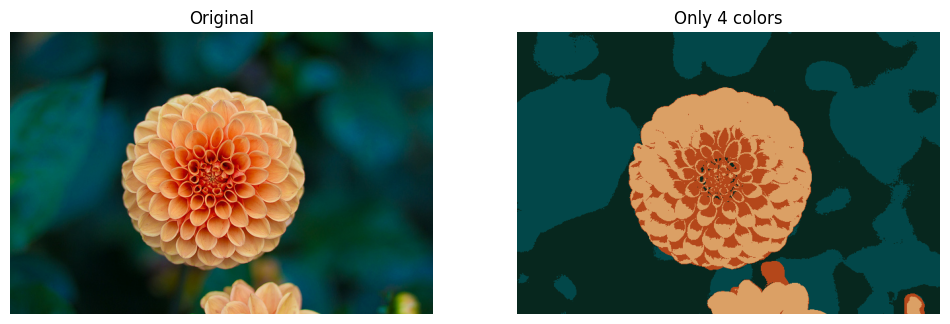

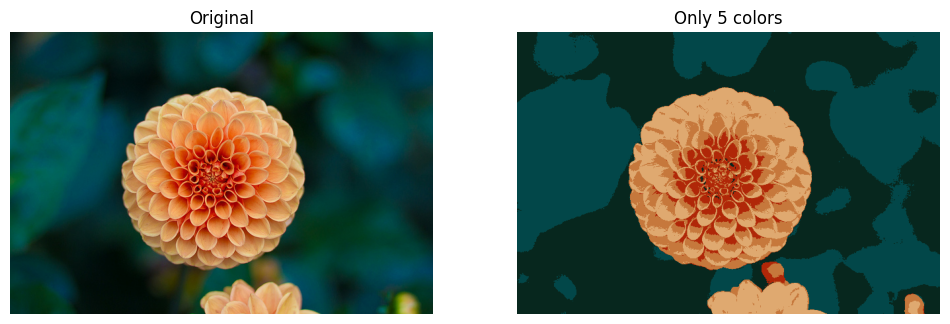

In [64]:
# YOUR CODE HERE
# Try a few different values of k
small, palette = repaint(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(photo); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(small); axes[1].set_title("Only 2 colors"); axes[1].axis("off")
plt.show()

small, palette = repaint(4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(photo); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(small); axes[1].set_title("Only 4 colors"); axes[1].axis("off")
plt.show()

small, palette = repaint(5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(photo); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(small); axes[1].set_title("Only 5 colors"); axes[1].axis("off")
plt.show()


---
# Final challenge - Can you beat 98.6%?

Your model used `kernel="rbf"` and `C=1`. Those were just guesses. Try some others:

- `kernel` - the shape of the boundary: `"linear"`, `"poly"`, or `"rbf"`
- `C` - how stubbornly it refuses to make mistakes: `0.1`, `1`, `10`, or `100`

Build one model for each `kernel` in the list, train it, and print its accuracy.
Which wins? Write your best score on the board.

In [71]:
for kernel in ["linear", "poly", "rbf"]:
    # YOUR CODE HERE
    # Build a model with this kernel, fit it, and print the accuracy
    for c in [0.1, 1, 10, 100]:
      clf = svm.SVC(kernel=kernel, C=c)
      clf.fit(X_train, y_train)
      y_pred = clf.predict(X_test)
      print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
      pass
    #poly with c=1 is best

Accuracy: 0.9778
Accuracy: 0.9778
Accuracy: 0.9778
Accuracy: 0.9778
Accuracy: 0.975
Accuracy: 0.9917
Accuracy: 0.9861
Accuracy: 0.9861
Accuracy: 0.95
Accuracy: 0.9861
Accuracy: 0.9861
Accuracy: 0.9861


**Finished early?** Try these:

1. Loop over `C` values too and find the best combination.
2. Swap the SVM for a completely different model:
   `from sklearn.neighbors import KNeighborsClassifier`, then
   `model = KNeighborsClassifier()`. Does it beat the SVM? Does it survive the
   one-pixel shift from Mission 5 any better?

---
## What you learned today

- An image is a grid of numbers. That's the whole bridge from pictures to math.
- **Train / test split** is non-negotiable. Testing on training data is lying to yourself.
- `fit()` then `predict()` - **every** model in scikit-learn works this way. You now know
  the pattern for the entire library.
- Looking at the actual mistakes tells you more than the accuracy number does.
- Models are **brittle**. One pixel of shift wrecked yours. Knowing where a model breaks
  is more useful than knowing where it works.
- Unsupervised learning finds patterns with **no answers at all**.

Nice work, detective.